# Ola Bike Ride Demand Forecasting Using Machine Learning

Name: Jerard M Francis

Reg no: 12310619

Roll no: 14

## Problem Statement

Ola bike ride demand varies depending on factors such as weather conditions, temperature, humidity, seasonal changes, and time of the day. Incorrect estimation of ride demand can lead to problems such as driver shortages, increased customer waiting time, and inefficient resource allocation.

The objective of this project is to develop a Machine Learning model that can accurately forecast Ola bike ride demand using historical ride and environmental data. The project uses Random Forest Regression to analyze patterns in the dataset and predict future ride demand, helping improve operational efficiency and customer satisfaction.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings('ignore')

## Load dataset and basic details

In [2]:
df = pd.read_csv('/content/ola.csv')
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137


In [3]:
df.shape

(10886, 9)

In [4]:
df.columns

Index(['datetime', 'season', 'weather', 'temp', 'humidity', 'windspeed',
       'casual', 'registered', 'count'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   temp        9254 non-null   float64
 4   humidity    9254 non-null   float64
 5   windspeed   9254 non-null   float64
 6   casual      10886 non-null  int64  
 7   registered  10886 non-null  int64  
 8   count       10886 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 765.6+ KB


In [6]:
df.describe()

,season,weather,temp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,9254.000000,9254.000000,9254.000000,10886.000000,10886.000000,10886.000000
mean,2.493937,2.491916,23.240116,124.452421,34.549616,24.517545,99.551442,224.177267
std,1.120531,1.123139,20.311144,75.568291,28.417263,14.390014,57.541131,75.228602
min,1.000000,1.000000,-22.743852,32.713561,-1.407737,0.000000,0.000000,-12.769738
25%,1.000000,1.000000,12.470555,87.846187,17.963252,12.000000,50.000000,170.140221
50%,2.000000,2.000000,20.743790,112.180064,30.945593,25.000000,100.000000,224.257587
75%,3.000000,4.000000,29.394576,137.301002,44.029018,37.000000,149.000000,278.407366
max,4.000000,4.000000,211.102548,672.687236,244.921965,49.000000,199.000000,464.839068


In [7]:
df.dtypes

,0
datetime,object
season,int64
weather,int64
temp,float64
humidity,float64
windspeed,float64
casual,int64
registered,int64
count,float64


### Datetime Conversion

The datetime column was converted into datetime format for extracting time-based features.

In [8]:
df['datetime'] = pd.to_datetime(df['datetime'])

## Data Cleaning


In [9]:
df.isnull().sum()

,0
datetime,0
season,0
weather,0
temp,1632
humidity,1632
windspeed,1632
casual,0
registered,0
count,0


In [10]:
df.duplicated().sum()

np.int64(0)

Missing values were removed using dropna() to improve data quality and model performance.

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

,0
datetime,0
season,0
weather,0
temp,0
humidity,0
windspeed,0
casual,0
registered,0
count,0


## Feature Engineering

Feature Engineering is the process of creating useful input features from existing data to improve Machine Learning model performance.

---

# Convert Datetime Column

In [13]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year

In [14]:
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,hour,day,month,year
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,0,1,1,2011
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,1,1,1,2011
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2,1,1,2011
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,3,1,1,2011
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,4,1,1,2011


### Outlier Removal

Extreme outliers in humidity and windspeed were removed to improve data quality and visualization clarity.

In [15]:
df = df[df['humidity'] < 200]

In [16]:
df = df[df['windspeed'] < 100]

## Exploratory Data Analysis (EDA)


In [17]:

OLA_GREEN  = "#48BB78"
OLA_DARK   = "#1A365D"
OLA_ORANGE = "#ED8936"
OLA_YELLOW = "#ECC94B"
PALETTE    = [OLA_GREEN, OLA_ORANGE, OLA_YELLOW, "#63B3ED", "#FC8181"]


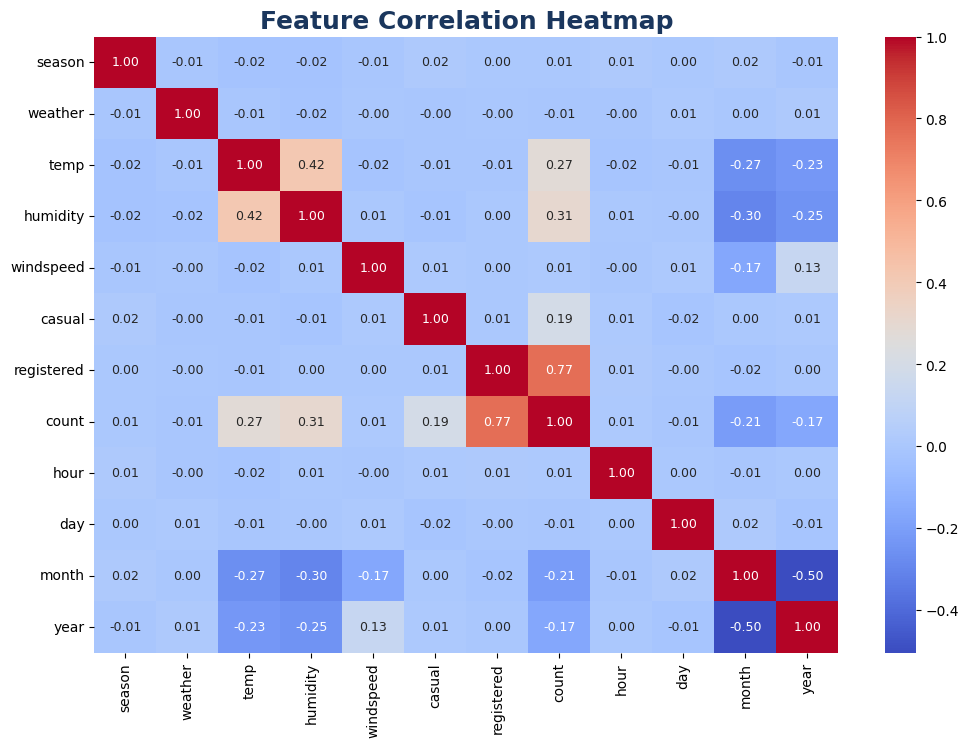

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    annot_kws={"size":9}
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=18,
    fontweight="bold",
    color=OLA_DARK
)

plt.show()

### Insights from Correlation Heatmap

- Registered users have the strongest positive correlation with ride demand.
- Temperature has a moderate positive relationship with demand.
- Weather conditions show weak negative correlation with ride count.
- Month and year show slight negative correlations with demand.

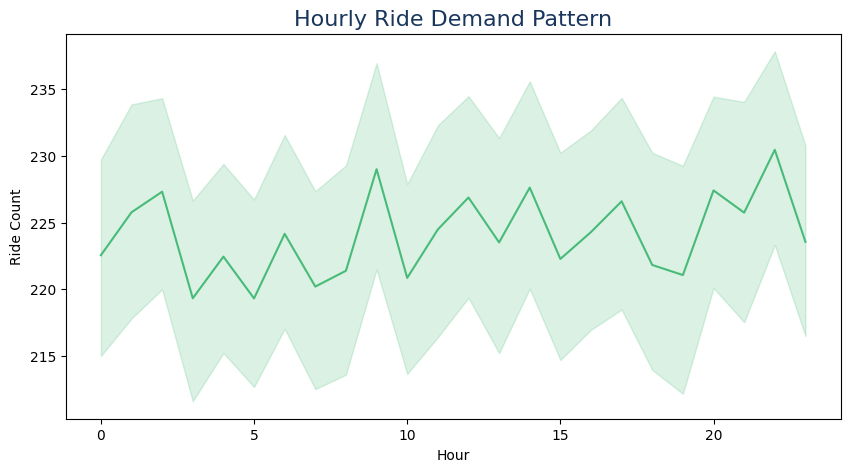

In [19]:
#Hourly Ride Demand Pattern


plt.figure(figsize=(10,5))

sns.lineplot(
    x='hour',
    y='count',
    data=df,
    color=OLA_GREEN
)

plt.title(
    'Hourly Ride Demand Pattern',
    color=OLA_DARK,
    fontsize=16
)

plt.xlabel('Hour')
plt.ylabel('Ride Count')

plt.show()

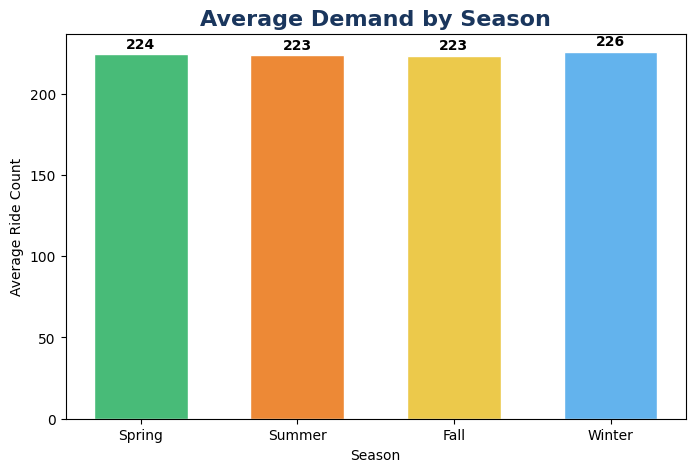

In [20]:
# Average Demand by Season

plt.figure(figsize=(8,5))

season_avg = (
    df.groupby("season")["count"]
    .mean()
    .reindex([1, 2, 3, 4])
)
bars = plt.bar(
    ["Spring", "Summer", "Fall", "Winter"],
    season_avg.values,
    color=PALETTE[:4],
    edgecolor="white",
    width=0.6
)

plt.title(
    "Average Demand by Season",
    fontsize=16,
    fontweight="bold",
    color=OLA_DARK
)

plt.xlabel("Season")
plt.ylabel("Average Ride Count")


for bar, val in zip(bars, season_avg.values):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.show()

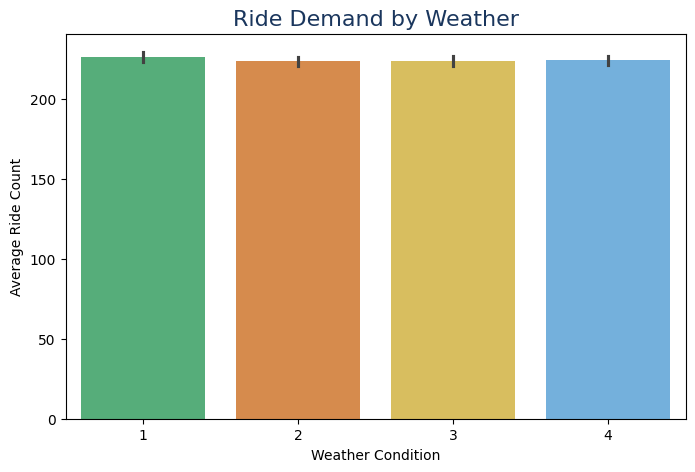

In [21]:
#Ride Demand by Weather


plt.figure(figsize=(8,5))

sns.barplot(
    x='weather',
    y='count',
    data=df,
    palette=PALETTE
)

plt.title(
    'Ride Demand by Weather',
    color=OLA_DARK,
    fontsize=16
)

plt.xlabel('Weather Condition')
plt.ylabel('Average Ride Count')

plt.show()

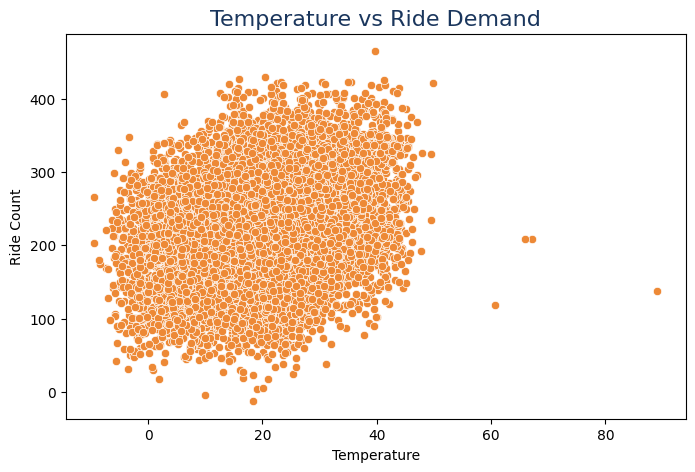

In [22]:
#Temperature vs Ride Demand
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='temp',
    y='count',
    data=df,
    color=OLA_ORANGE
)

plt.title(
    'Temperature vs Ride Demand',
    color=OLA_DARK,
    fontsize=16
)

plt.xlabel('Temperature')
plt.ylabel('Ride Count')

plt.show()

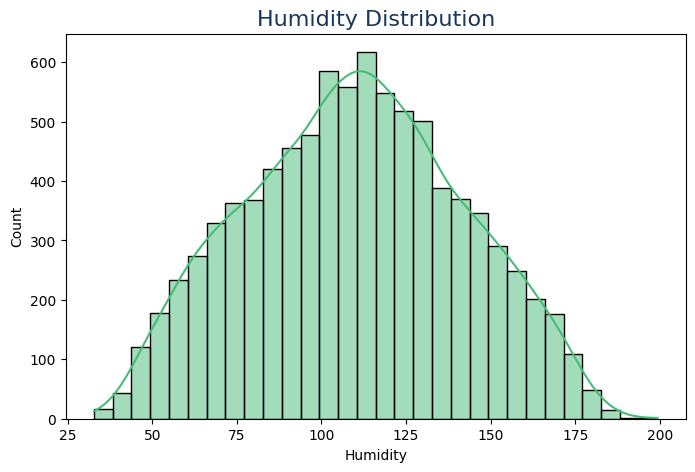

In [23]:
#Humidity Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['humidity'],
    bins=30,
    kde=True,
    color=OLA_GREEN
)

plt.title(
    'Humidity Distribution',
    color=OLA_DARK,
    fontsize=16
)

plt.xlabel('Humidity')

plt.show()

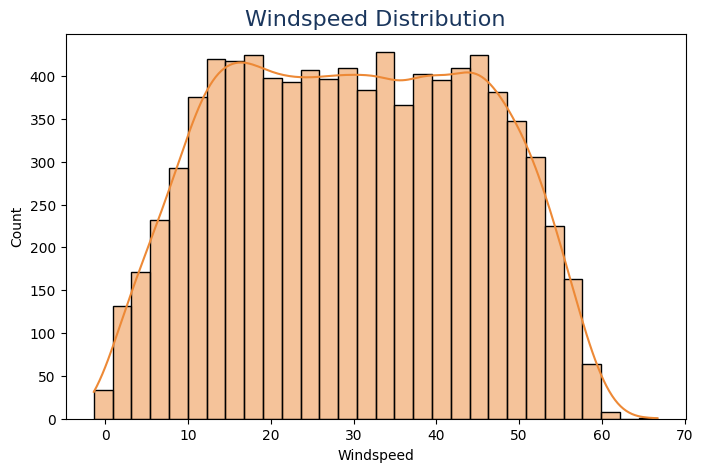

In [24]:
#Windspeed Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['windspeed'],
    bins=30,
    kde=True,
    color=OLA_ORANGE
)

plt.title(
    'Windspeed Distribution',
    color=OLA_DARK,
    fontsize=16
)

plt.xlabel('Windspeed')

plt.show()

## Feature Selection

In [25]:
X = df[['season',
        'weather',
        'temp',
        'humidity',
        'windspeed',
        'casual',
        'registered',
        'hour',
        'day',
        'month',
        'year']]

In [26]:
y = df['count']

In [27]:
X.head()

,season,weather,temp,humidity,windspeed,casual,registered,hour,day,month,year
0,3,2,7.653428,122.430885,18.783703,5,128,0,1,1,2011
1,4,3,13.269244,101.703802,14.035245,36,184,1,1,1,2011
2,1,3,30.886922,77.583743,45.365080,34,97,2,1,1,2011
3,3,1,10.463377,114.925671,25.347168,6,47,3,1,1,2011
4,3,4,30.214783,149.193592,20.288982,14,199,4,1,1,2011


In [28]:
y.head()

,count
0,315.731778
1,340.457093
2,224.278595
3,132.169549
4,315.867137


## Data splitting

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
print("X_train Shape:", X_train.shape)

print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)

print("y_test Shape:", y_test.shape)

X_train Shape: (7044, 11)
X_test Shape: (1761, 11)
y_train Shape: (7044,)
y_test Shape: (1761,)


## Model Training


Train the Machine Learning Model

Random Forest Regressor is used to predict Ola bike ride demand based on weather and time-related features.


In [31]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

In [32]:
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=300, random_state=42)

## Prediction

After training the Random Forest model, predictions are made using the testing dataset.


Predict Ride Demand



In [33]:
predictions = model.predict(X_test)

In [34]:
print(predictions[:10])

[166.8759486  185.66126398  69.81212175 247.76353698 298.72517382
 142.69264443 180.06955374 235.19669159 320.41446486 281.73646397]


In [35]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

comparison.head(10)

,Actual,Predicted
7382,132.047819,166.875949
5294,173.669152,185.661264
6988,48.524098,69.812122
2075,232.423691,247.763537
1663,308.804147,298.725174
6070,155.867045,142.692644
3328,166.220688,180.069554
600,231.358440,235.196692
2056,319.108208,320.414465
6264,282.490478,281.736464


## Model Evaluation

In [36]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 25.792231194420115


In [37]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 32.352072269641404


In [38]:
r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.8196304245897132


In [39]:
print("Model Accuracy:", round(r2*100,2), "%")

Model Accuracy: 81.96 %


## 1 Feature Importance Graph

In [40]:
importance = model.feature_importances_

features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

       Feature  Importance
6   registered    0.611887
9        month    0.130793
10        year    0.073654
5       casual    0.058721
3     humidity    0.024806
2         temp    0.024517
4    windspeed    0.023455
8          day    0.020658
7         hour    0.017622
1      weather    0.007019
0       season    0.006867


## 2. Actual vs Predicted Graph

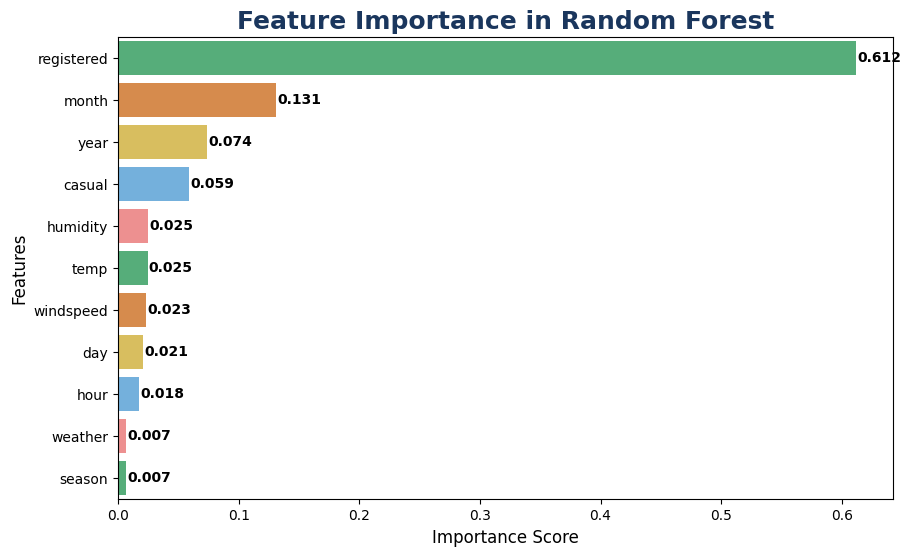

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance,
    palette=PALETTE
)

plt.title(
    'Feature Importance in Random Forest',
    fontsize=18,
    fontweight='bold',
    color=OLA_DARK
)

plt.xlabel(
    'Importance Score',
    fontsize=12
)

plt.ylabel(
    'Features',
    fontsize=12
)

# Add values on bars

for index, value in enumerate(feature_importance['Importance']):

    plt.text(
        value + 0.001,
        index,
        f"{value:.3f}",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

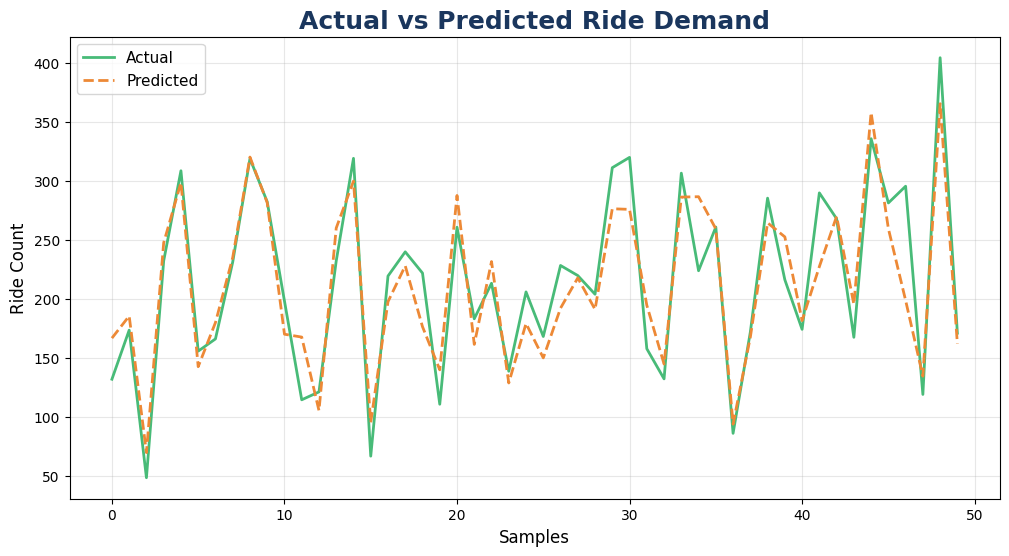

In [42]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:50],
    label='Actual',
    color=OLA_GREEN,
    linewidth=2
)

plt.plot(
    predictions[:50],
    label='Predicted',
    color=OLA_ORANGE,
    linewidth=2,
    linestyle='--'
)

plt.title(
    'Actual vs Predicted Ride Demand',
    fontsize=18,
    fontweight='bold',
    color=OLA_DARK
)

plt.xlabel(
    'Samples',
    fontsize=12
)

plt.ylabel(
    'Ride Count',
    fontsize=12
)

plt.legend(
    fontsize=11
)

plt.grid(
    alpha=0.3
)

plt.show()

## 3. Final Insights





Project Insights

1. Registered users contribute most to ride demand.
2. Weather and temperature affect booking patterns.
3. Ride demand changes with seasonal variations.
4. Random Forest performed well for demand forecasting.
5. Removing missing values improved model accuracy.

## Final Result



The Random Forest Regressor model achieved approximately 82% prediction accuracy and successfully forecasted Ola bike ride demand using weather, seasonal, and user-related features.

## Conclusion



The Random Forest Regressor model successfully predicted Ola bike ride demand using weather, seasonal, and user-related features. After preprocessing and hyperparameter tuning, the model achieved an R² score of 0.819, indicating good prediction accuracy. The project demonstrates how Machine Learning can help optimize ride allocation and improve transportation services.